# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Nur Aidah K. S.
- **Email:** nuraidah.pknstan@gmail.com
- **ID Dicoding:** run_hadia

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1

Bagaimana tren kualitas udara (PM2.5/PM10) dalam beberapa tahun terakhir? Apakah terdapat pola waktu tertentu di mana polusi udara mencapai puncaknya?
- Pertanyaan 2

Pada jam berapakah polusi udara cenderung paling tinggi dan paling rendah dalam satu hari? Apakah pola ini konsisten antara hari kerja (weekday) dan akhir pekan (weekend)?
- Pertanyaan 3

Stasiun manakah yang memiliki kualitas udara terburuk dan terbaik secara rata-rata? Bagaimana perbandingan komposisi polutan (SO2, NO2, CO, O3) antar lokasi tersebut?

## Import Semua Packages/Library yang Digunakan

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob


## Data Wrangling

### Gathering Data

In [21]:
#Load Data (terdapat 12 files)
file_pattern = "PRSA_Data_*.csv"
csv_files = glob.glob(file_pattern)

# Membaca dan menggabungkan semua file csv
df_list = []

#
for file in csv_files:
  df = pd.read_csv(file).drop(['No'], axis=1)
  df_list.append(df)

# Menggabungkan df_list menjadi satu DataFrame utama
main_df = pd.concat(df_list, ignore_index=True)

# Mencetak 5 baris data pertama
print(main_df.head())

   year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  \
0  2013      3    1     0    3.0   6.0  13.0   7.0  300.0  85.0  -2.3  1020.8   
1  2013      3    1     1    3.0   3.0   6.0   6.0  300.0  85.0  -2.5  1021.3   
2  2013      3    1     2    3.0   3.0  22.0  13.0  400.0  74.0  -3.0  1021.3   
3  2013      3    1     3    3.0   6.0  12.0   8.0  300.0  81.0  -3.6  1021.8   
4  2013      3    1     4    3.0   3.0  14.0   8.0  300.0  81.0  -3.5  1022.3   

   DEWP  RAIN   wd  WSPM    station  
0 -19.7   0.0    E   0.5  Changping  
1 -19.0   0.0  ENE   0.7  Changping  
2 -19.9   0.0  ENE   0.2  Changping  
3 -19.1   0.0  NNE   1.0  Changping  
4 -19.4   0.0    N   2.1  Changping  


**Insight:**
Air Quality Dataset adalah Kumpulan data per jam yang mempertimbangkan 6 polutan udara utama dan 6 variabel meteorologi yang relevan di beberapa lokasi di Beijing.

- Subject area dataset: climate dan enviroment
- Dataset terdiri dari 12 file CSV yang terpisah yang mewakili 12 stasiun berbeda di Beijing
- Total data mentah yang diperoleh 420.768 baris dengan 18 kolom.
- Karakteristik dataset adalah multivariate dan time-series
- Tipe feature adalah integer, real

dataset dapat dikelompokkan dalam 4 kategori utama yaitu



#### 1.   Kategori identitas & Waktu
Kolom-kolom ini mencatat identitas dan kapan data tersebut diambil. data direkam setiap jam (hourly)
- Year: tahun pengambilan data berisi data dari tahun 2013 hingga 2017
- month: bulan pengambilan data (angka 1 untuk Januari hingga angka 12 untuk Desember)
- day: hari dalam bulan tersebut (angka 1 hingga 31)
- hour: jam pengambilan data dalam format 24 jam (angka 0 berarti tengah malam, angka 23 berarti jam 11 malam)


#### 2. Kategori Polutan / Kualitas Udara
Kategori ini yang akan dianalisis secara mendalam dan menjadi inti. semua kolom dalam kategori diukur dalam satuan µg/m³ (mikrogram per meter kubik). semakin tinggi nilainya, semakin buruk kondisi udarannya.
  - PM2.5: konsentrasi partikel halus yang berukuran 2.5 mikrometer atau lebih kecil. PM2.5 sebagai indikator utama karena partikel ini paling sering digunakan sebagai indikator acuan kesehatan (indeks ISPU/AQI)
  - PM10: Konsentrasi parikel berukuran  mikrometer atau lebih kecil. ini biasanya berupa debu kasar, serbuk sari, atau asap
  - SO2 / Sulfur Dioksida: Gas beracun yang baunya menyengat, biasanya berasal dari pembakaran batu bara di pabrik atau pembangkit listrik
  - NO2 / Nitrogen Dioksida: Gas beracun yang sebagian besar dihasilkan dari asap knalpot kendaraan bermotor.
  - CO / Karbon Monoksida: Gas mematikan yang tidak berwarna dan berbau, berasal dari sisa pembakaran kendaraan bermotor yang tidak sempurna
  - O3 / Ozon: ozon yang berada di permukaan tanah adalah polutan berbahaya yang memicu asma dan sesak napas

  
####  3. Kategori Cuaca / Meteorologi
  Kolom dalam kategori ini akan mencatat kondisi cuaca pada jam tersebut.
  - TEMP / Temperature: suhu udara pada saat itu, diukur dalam derajat Celcius (°C)
  - PRES / Pressure: tekanan udara, diukur dalam satuan hPa (hektopaskal).
  - DEWP / Dew Point / Titik Embun: suhu dimana udara menjadi jenuh dan uap air mulai mengembun, berkaitan erat dengan kelembapan udara
  - RAIN / Hujan: curah hujan yang turun, diukur dalam milimeter (mm). jika nilainya 0, artinya tidak turun hujan
  - WD / Wind Direction: arah hembusan angin, format menggunakan arah mata angin. N untuk north, NW untuk Northwest/barat laut, SE untuk Southeast/tenggara dan lain-lain.
  - WSPM / Wind Speed: kecepatan angin. diukur dalam meter per detik (m/s)


#### 4. Kategori Lokasi
- Station: nama stasiun pemantauan kualitas udara yang merekam data tersebut, terdapat 12 nama statiun yaitu Aotizhongxin, Changping, Dingling, Dongsi, Guanyuan, Gucheng, Huairou, Nongzhanguan, Shunyi, Tiantan, Wanliu, Wanshouxigong.

### Assessing Data

In [22]:
# 1. Ringkasan Statistik
print("1. Memeriksa Ringkasan Statistik")
print(main_df.describe())

# 2. Menghitung total duplikasi data (keseluruhan baris)
total_duplikat = main_df.duplicated().sum()
print(f"\nTotal Duplikasi Data (Seluruh Baris): {total_duplikat} baris\n")

# 3. Membuat tabel ringkasan per kolom
df_summary = pd.DataFrame({
    'Nama Kolom': main_df.columns,
    'Tipe Data': main_df.dtypes.astype(str),
    'Missing Value': main_df.isna().sum(),
    'Persentase Missing (%)': round((main_df.isna().sum() / len(main_df)) * 100, 2),
    'Jumlah Nilai Unik': main_df.nunique()
}).reset_index(drop=True) # Reset index agar rapi dari 0, 1, 2, dst.

# 3. Menampilkan tabel (panggil nama variabelnya)
df_summary


1. Memeriksa Ringkasan Statistik
                year          month            day           hour  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean     2014.662560       6.522930      15.729637      11.500000   
std         1.177198       3.448707       8.800102       6.922195   
min      2013.000000       1.000000       1.000000       0.000000   
25%      2014.000000       4.000000       8.000000       5.750000   
50%      2015.000000       7.000000      16.000000      11.500000   
75%      2016.000000      10.000000      23.000000      17.250000   
max      2017.000000      12.000000      31.000000      23.000000   

               PM2.5           PM10            SO2            NO2  \
count  412029.000000  414319.000000  411747.000000  408652.000000   
mean       79.793428     104.602618      15.830835      50.638586   
std        80.822391      91.772426      21.650603      35.127912   
min         2.000000       2.000000       0.285600       1.026500   


,Nama Kolom,Tipe Data,Missing Value,Persentase Missing (%),Jumlah Nilai Unik
0,year,int64,0,0.00,5
1,month,int64,0,0.00,12
2,day,int64,0,0.00,31
3,hour,int64,0,0.00,24
4,PM2.5,float64,8739,2.08,888
5,PM10,float64,6449,1.53,1084
6,SO2,float64,9021,2.14,691
7,NO2,float64,12116,2.88,1212
8,CO,float64,20701,4.92,132
9,O3,float64,13277,3.16,1598


**Insight:**
Berdasarkan proses assessment, ditemukan beberapa insight sebagai berikut:

#### 1) Statistical Summary
Berikut beberapa insight menarik dari angka ringkasan statistik:

##### - Indikator Kualitas Udara (PM2.5)
Nilai rata-rata /mean adalah 78.79 µg/m³. nilai minimum adalah 2 µg/m³ (sangat bersih), namun nilai maksimumnya mencapai 999 µg/m³ (sangat beracun dan berbahaya). Nilai tengah/median (Q2 atau 50%) adalah 55 µg/m³, yang berarti distribusi polusi condong ke kanan (banyak outlier saat polusi ekstrim)

##### - Suhu Udara (TEMP)
Suhu udara terendah tercatat mencapai-19.9 °C, sedangkan suhu terpanas mencapai 41.6 °C. Ini mencerminkan iklim empat musim di Beijing yang cukup ekstrem.

##### - Curah Hujan (RAIN)
Mayoritas waktu bernilai 0 mm (dilihat dari Kuartil 1, Median, hingga Kuartil 3 yang nilainya 0), yang berarti sebagian besar jam dalam 4 tahun tersebut tidak terjadi hujan. Namun, saat curah hujan maksimum, dapat mencapai 72.5 mm per jam.

##### - Waktu Pengamatan
Data tercatat secara merata dari Jam 0 sampai dengan Jam 23

#### 2) Tipe Data
Tipe data dalam dataset ini terbagi menjadi 3 jenis yaitu:
#####- Integer
Tipe data integer dalam kolom year, month, day, hour. Kolom tanggal masih terpisah-pisah sehingga perlu disatukan menjadi format datatime agar bisa dianalisis berdasarkan waktu atau time-series
#####- Float
Tipe data float dalam kolom PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM. kategori kualitas udara dan cuaca tercatat dalam bentuk desimal yang bagus dalam perhitungan matematika
#####- Object (teks/string)
Tipe data string dalam kolom wd dan station.


#### 3) Missing Value / Data kosong
Dari total 420.768 baris, terdapat 12 dari 18 kolom memiliki missing values (NaN), dengan rincian:
- Polutan
    - CO: 20.701 baris (terbesar)
    - O3: 13.277 baris
    - NO2: 12.116 baris
    - SO2: 9.021 baris
    - PM2.5: 8.739 baris
    - PM10: 6.449 baris (terkecil)

- Cuaca
    - WD: 1.822 baris (terbesar)
    - DEWP: 403 baris
    - TEMP: 398 baris
    - PRES: 393 baris
    - RAIN: 390 baris
    - WSPM: 318 baris(terkecil)

Adanya missing values yang banyak pada kolom polutan mengindikasikan bahwa alat sensor di stasiun pemantau cuaca kemungkinan sering mengalami downtime, error atau dalam proses maintenance. selain itu, kategori cuaca/meteorologi memiliki missing values yang lebih kecil dibandingkan kategori polutan. Hal ini menjelaskan bahwa data sensor cuaca lebih mudah di dapatkan atau diukur dibandingkan sensor partikel mikroskopis.


#### 4)Duplikat Data / Duplicates
Jumlah data duplikat adalah 0 baris. Hal ini menunjukkan tidak terdapat data identik yang tercatat dalam keseluruhan dataset, sehingga tidak perlu drop duplicates.

### Cleaning Data

In [23]:
main_df_clean = main_df.copy()

#Memperbaiki Tipe Data dengan membuat kolom datatime
main_df_clean['datetime'] = pd.to_datetime(main_df_clean[['year', 'month', 'day', 'hour']])

#Menghapus kolom lama yang tidak terpakai
main_df_clean.drop(columns=['year', 'month', 'day', 'hour'], inplace=True)

#Menangani Missing Values untuk kolom kualitas udara
cols_subset = ['PM2.5']
rows_before = main_df_clean.shape[0]
main_df_clean.dropna(subset=cols_subset, inplace=True)
rows_after = main_df_clean.shape[0]
print(f"Sisa data bersih sebanyak: {rows_after} baris.\n")

# Menggunakan metode INTERPOLASI (menebak nilai di antara dua titik waktu)
polutan_cols = ['PM10', 'SO2', 'NO2', 'CO', 'O3']
main_df_clean[polutan_cols] = main_df_clean[polutan_cols].interpolate(method='linear', limit_direction='both')

#Menangani Missing values untuk kolom cuaca
weather_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
main_df_clean[weather_cols] = main_df_clean[weather_cols].ffill()

#Menghitung total baris data yang tersisa setelah cleaning
total_baris_bersih = len(main_df_clean)
print(f"Kondisi Data Setelah Cleaning (Total: {total_baris_bersih} baris)\n")

#Membuat tabel ringkasan untuk data yang sudah bersih
df_summary_clean = pd.DataFrame({
    'Nama Kolom': main_df_clean.columns,
    'Tipe Data': main_df_clean.dtypes.astype(str),
    'Missing Value': main_df_clean.isna().sum(),
    'Persentase Missing (%)': round((main_df_clean.isna().sum() / total_baris_bersih) * 100, 2),
    'Jumlah Nilai Unik': main_df_clean.nunique(),
    'Jumlah Baris Data': total_baris_bersih  # Menampilkan total baris di setiap kolom
}).reset_index(drop=True)

#Menampilkan tabel hasil cleaning data
df_summary_clean

Sisa data bersih sebanyak: 412029 baris.

Kondisi Data Setelah Cleaning (Total: 412029 baris)



,Nama Kolom,Tipe Data,Missing Value,Persentase Missing (%),Jumlah Nilai Unik,Jumlah Baris Data
0,PM2.5,float64,0,0.00,888,412029
1,PM10,float64,0,0.00,1194,412029
2,SO2,float64,0,0.00,2533,412029
3,NO2,float64,0,0.00,5238,412029
4,CO,float64,0,0.00,8457,412029
5,O3,float64,0,0.00,6094,412029
6,TEMP,float64,0,0.00,2018,412029
7,PRES,float64,0,0.00,726,412029
8,DEWP,float64,0,0.00,645,412029
9,RAIN,float64,0,0.00,250,412029


**Insight:**
#### - Mengubah Tipe Data menjadi Datatime
Setelah proses assesment diketahui data kategori waktu terpisah menjadi 4 kolom dengan tipe data integer yaitu year, month, day, dan hour. Contohnya 2013, 3, 1, 0. Untuk itu, keempat kategori waktu perlu dijadikan satu stempel waktu universal dengan fungsi pd.to_datetime(). Dengan tipe datetime, pandas akan menerapkan konsep hirarki kalender. Penerapan ini akan membantu dalam resampling untuk menghitung rata-rata polusi setiap bulan. Selain itu, untuk membuat line chart di mana sumbu X otomatis diformat menjadi tahun/bulan, tidak menjadi rentang angka-angka yang acak jika masih menggunakan tipe data integer.

####- Menangani Missing Values di kolom PM2.5 dengan dropna
Target utama analisis adalah kualitas udata yang diwakili secara general oleh kolom PM2.5. Dalam kolom PM2.5 terdapat missing values sebanyak 8.739 baris. Untuk menangani missing values tersebut digunakan dropna untuk menghapus baris yang kosong. Kenapa tidak dilakukan imputasi? karena kadar polusi bersifat fruktuatif dan dipengaruhi banyak faktor dinamis. Mengisi missing value pada 8.739 baris dengan rata-rata harian atau rata-rata bulanan akan merusak keaslian trend dan menyesatkan dalam pengambilan kesimpulan. Dalam kasus target variabel yang fluktuatif, membuang/menghapus data sebesar 2.08% dari total data menjadi pilihan yang baik daripada mengisi dengan perkiraan ataupun menciptakan polusi buatan berdasarkan nilai rata-rata. Fokus utama proyek dan pertanyaan bisnis menitikberatkan pada PM2.5 sebagai indikator utama kualitas udara sehingga akan membiarkan missing values di polutan sekunder. Hal ini dimaksudkan untuk menjaga efisiensi dan akurasi analisis kualitas udara. (Catatan: Jika dibutuhkan untuk menganalisis korelasi SO2, cukup handling khusus hanya saat analisis SO2 tersebut).

#####- Mengisi Missing values di kolom PM10, SO2, NO2, CO dan O3 menggunakan Interpolasi
Jika menghapus baris yang kosong di semua kolom polutan sekaligus (misalnya main_df.dropna(subset=['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3'])), kita akan kehilangan terlalu banyak baris data. untuk itu digunakan interpolasi linear.
Diimputasi menggunakan Linear Interpolation. Mengingat sifat polusi udara yang bergerak kontinu, interpolasi adalah pendekatan terbaik untuk memperkirakan nilai yang hilang berdasarkan tren jam sebelum dan sesudahnya tanpa membuang baris data. ika polusi jam 08:00 adalah 100, lalu jam 09:00 sensornya mati (missing), dan jam 10:00 polusinya 150, maka Interpolasi akan menebak secara matematis bahwa polusi jam 09:00 kemungkinan besar berada di tengah-tengahnya, yaitu 125.

#####- Mengisi Kolom Cuaca dengan Forward Fill/ ffill
Forward fill atau DataFrame.ffill() digunakan untuk mengambil nilai terakhir yang valid dan mengisinya ke bawah pada sel yang kosong. Kolom cuaca menggunakan fungsi ini karena didasarkan pada prinsip ilmu atmosfer (meteorology), di mana cuaca adalah entitas fisik yang bersifat kontinu, perubahannya terjadi berangsur-angsur atau gradual (tidak melompat drastis). Misalnya suhu udara tidak akan melompat dari 15°C pada jam 09:00 langsung menjadi 30°C pada jam 10:00, lalu kembali ke 15°C pada jam 11:00. Jika suhu jam 10:00 kosong (sensor mati sebentar), perkiraan suhunya 15°C atau sama dengan jam 09:00 adalah perkiraan yang logis secara fisika dan jauh lebih baik daripada mengisi dengan rata-rata suhu setahun. Begitupun dengan tekanan udara/PRES dan titik embun/DEWP juga bergerak sangat lambat dari jam ke jam. Berbeda dengan cuaca yang perlahan, polusi (PM2.5) bisa melonjak instan hanya dalam hitungan menit. Misalnya, tiba-tiba ada pabrik yang membuang asap tebal di sebelah sensor, atau angin kencang tiba-tiba datang menyapu debu. Itulah alasan kenapa ffill digunakan untuk cuaca fisik (suhu/tekanan), tapi sangat berbahaya jika diterapkan pada polusi kimia.

## Exploratory Data Analysis (EDA)

### Explore Kualitas Udara (PM2.5)

               PM2.5           PM10            SO2            NO2  \
count  412029.000000  412029.000000  412029.000000  412029.000000   
mean       79.793428     104.810711      15.842810      50.673670   
std        80.822391      92.241819      21.643518      35.184344   
min         2.000000       2.000000       0.285600       1.026500   
25%        20.000000      36.000000       3.000000      23.000000   
50%        55.000000      82.000000       7.000000      43.000000   
75%       111.000000     145.000000      20.000000      71.000000   
max       999.000000     999.000000     500.000000     290.000000   

                  CO             O3  
count  412029.000000  412029.000000  
mean     1234.955415      56.921649  
std      1161.319229      56.978183  
min       100.000000       0.214200  
25%       500.000000      10.000000  
50%       900.000000      44.000000  
75%      1500.000000      81.000000  
max     10000.000000    1071.000000  


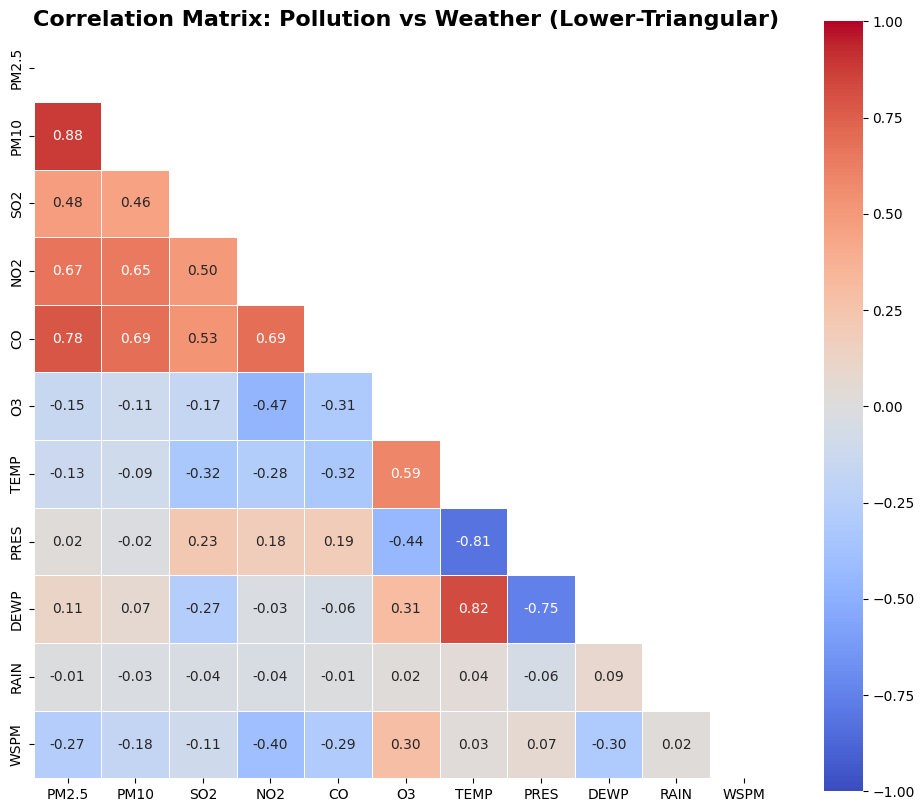

/tmp/ipython-input-2941409769.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


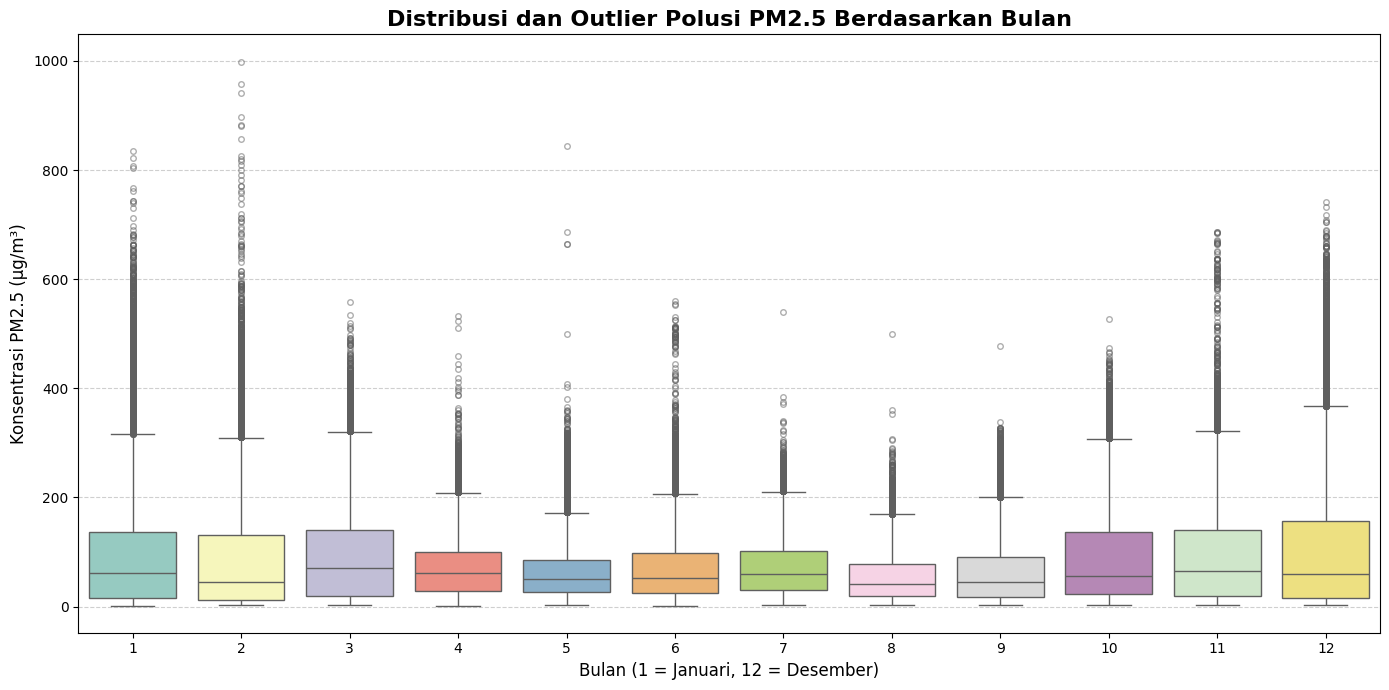

/tmp/ipython-input-2941409769.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


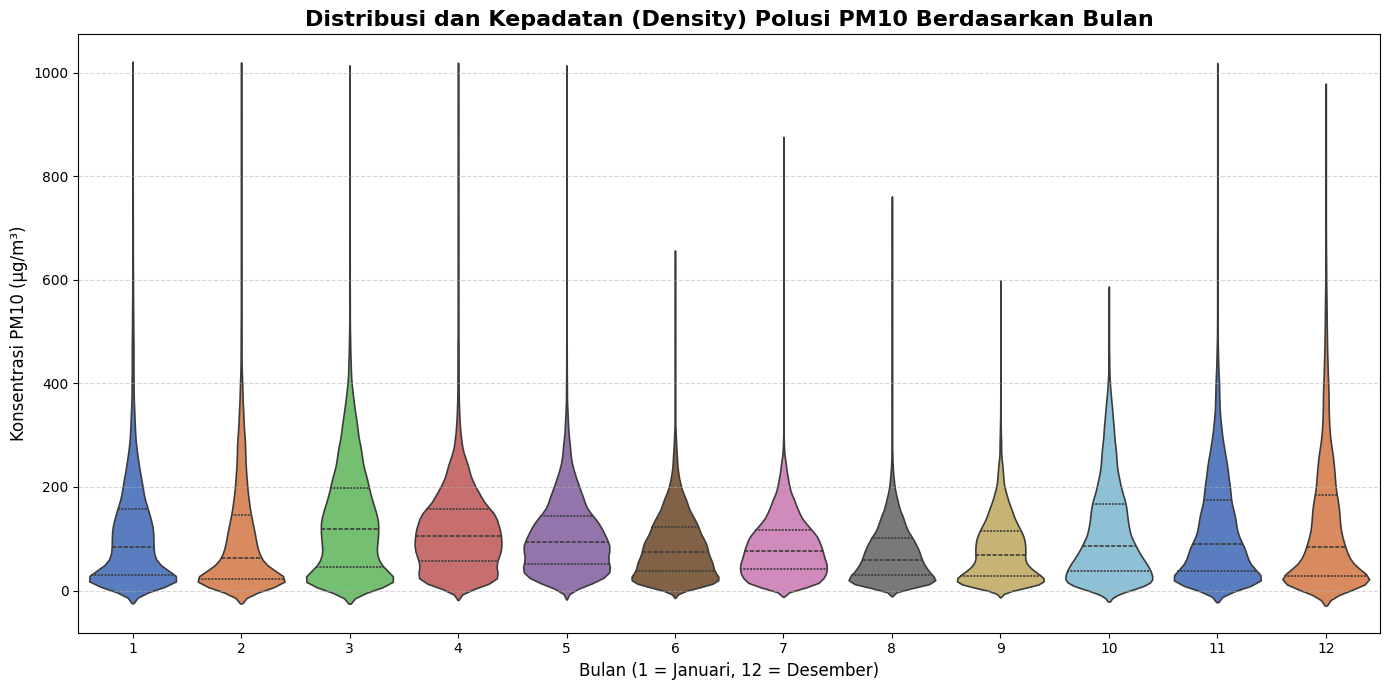

In [24]:
#Melihat rangkuman parameter polusi utama
pollution_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print(main_df_clean[pollution_cols].describe())

# Melihat korelasi antar variabel numerik
plt.figure(figsize=(12, 10)) # Diperbesar sedikit agar angkanya lebih lega terbaca

# Menghitung matriks korelasi
kolom_korelasi = pollution_cols + ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
correlation_matrix = main_df_clean[kolom_korelasi].corr(numeric_only=True)

# Membuat 'mask' untuk menyembunyikan segitiga bagian atas
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Membuat heatmap dengan mask dan penyesuaian estetika
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',  # Kamu tetap bisa pakai coolwarm
    fmt=".2f",
    mask=mask,        # Memasukkan mask ke dalam grafik
    vmin=-1, vmax=1,  # Memastikan skala warna seimbang dari -1 hingga 1
    center=0,         # Menjadikan angka 0 sebagai warna netral di tengah
    square=True,      # Membuat kotaknya berbentuk persegi sempurna
    linewidths=.5     # Menambahkan garis putih tipis antar kotak agar lebih rapi
)

plt.title("Correlation Matrix: Pollution vs Weather (Lower-Triangular)", fontsize=16, fontweight='bold')
plt.show()

# Boxplot Distribusi PM2.5 berdasarkan bulan
plt.figure(figsize=(14, 7))

# Mengambil bulan dari kolom datetime untuk sumbu X
bulan = main_df_clean['datetime'].dt.month

# Membuat Boxplot menggunakan Seaborn
sns.boxplot(
    x=bulan,
    y=main_df_clean['PM2.5'],
    palette='Set3',
    showfliers=True,       # Menampilkan titik-titik outlier
    flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5) # Mengatur gaya titik outlier
)

plt.title('Distribusi dan Outlier Polusi PM2.5 Berdasarkan Bulan', fontsize=16, fontweight='bold')
plt.xlabel('Bulan (1 = Januari, 12 = Desember)', fontsize=12)
plt.ylabel('Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Violinplot Distribusi PM10

plt.figure(figsize=(14, 7))

# Membuat Violin Plot menggunakan Seaborn
sns.violinplot(
    x=bulan,
    y=main_df_clean['PM10'],
    palette='muted',        # Menggunakan palet warna 'muted' agar berbeda dari grafik PM2.5
    inner='quartile',       # Menampilkan garis kuartil di dalam "biola"
    linewidth=1.2
)

plt.title('Distribusi dan Kepadatan (Density) Polusi PM10 Berdasarkan Bulan', fontsize=16, fontweight='bold')
plt.xlabel('Bulan (1 = Januari, 12 = Desember)', fontsize=12)
plt.ylabel('Konsentrasi PM10 (µg/m³)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Insight:**
- Ringkasan Statistik,

Berdasarkan nilai statistik yang ditunjukan dapat diambil kesimpulan mengenai kualitas udara di Beijing sebagai berikut:
1. Rata-rata kadar PM2.5 tercatat pada angka 79.79 µg/m³. Angka ini jauh melebihi batas aman tahunan yang direkomendasikan oleh WHO, yaitu hanya 15 µg/m³. Lebih mengejutkan lagi, nilai maksimum PM2.5 pernah mencapai 999 µg/m³, yang mengindikasikan bahwa Beijing pernah mengalami hari-hari dengan kondisi polusi yang sangat ekstrem dan beracun (Hazardous).

2. Parameter Karbon Monoksida (CO) memiliki rentang nilai yang sangat lebar, dengan rata-rata 1231.72 µg/m³ dan nilai puncak mencapai 10.000 µg/m³. Tingginya nilai maksimum untuk gas-gas seperti NO2 (290 µg/m³) dan CO kemungkinan besar bertepatan dengan kemacetan lalu lintas yang parah.

- Heatmap

Berdasarkan Heatmap di atas, menunjukkan bahwa korelasi antara variabel polutan dan cuaca, terdapat beberapa insight sebagai berikut:

1. Korelasi antar polutan (Positif Kuat). Hal ini tampak dari adanya korelasi positif yang sangat kuat (di atas 0.88) antara PM2.5 dan PM10. Hal ini logis karena keduanya merupakan sumber polusi partikel yang seringkali dihasilkan dari proses yang sama (misalnya pembakaran atau debu jalanan). Jika PM10 tinggi, hampir bisa dipastikan PM2.5 juga tinggi. Tingkat PM2.5 yang tinggi sebanding dengan tingginya kadar SO2, NO2, dan CO menunjukkan kualitas udara yang buruk, namun cenderung memiliki korelasi yang lemah atau tidak memiliki korelasi dengan kadar ozon/O3.

2. Pengaruh kecepatan angin/WSPM terhadap PM2.5 berada di angka -0.27 (negatif sedang). Hal ini menunjukkan semakin kencang angin maka konsentrasi polusi PM2.5 cenderung menurun.


3. Pengaruh temperature/suhu terhadap PM2.5 juga negatif lemah berada di angka -0.13. Ini mengindikasikan bahwa polusi cenderung sedikit lebih tinggi saat suhu udara dingin. Hal ini sejalan dengan pola musiman di Tiongkok, di mana musim dingin memicu peningkatan pembakaran batu bara untuk pemanas ruangan, sehingga memproduksi emisi yang lebih besar.

4. Pressure/tekanan udara, dew point/titik embun dan rain/curah hujan cenderung memiliki korelasi yang sangat lemah atau tidak berkorelasi terhadap kenaikan atau penurunan kadar PM2.5

- Boxplot

Berdasarkan Boxplot di atas, menunjukkan sebaran dan nilai outliers, terdapat beberapa insight sebagai berikut:
Di setiap bulan, kotak berada di area bawah dan ekor berbentuk memanjang ke atas. ini menunjukkan bahwa distribusi PM2.5 cukup condong ke kanan. banyak hari memiliki polusi sedang namun ada hari-hari tertentu polusi memuncak ekstrem. jika diperhatikan titik-titik yang membentuk ekor memanjang pada bulan november hingga februari menujukkan rata-rata yang cukup tinggi di atas 600 µg/m³. sebaliknya bulan agustus s.d. september memiliki kotak yang paling pipih dan titik outlier yang sedikit.

- Violin plot

Berdasarkan grafik violin plot di atas, menunjukkan bahwa bulan Maret s.d. Mei (musim semi), leher biola masih menjulur tinggi menujukkan  masih cukup tinggi konsentrasi PM10. Selain itu, bentuk violin di bulan Agustus s.d. September berbentuk pipih dengan distribusi paling padat menunjukkan partikel PM10 cukup rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

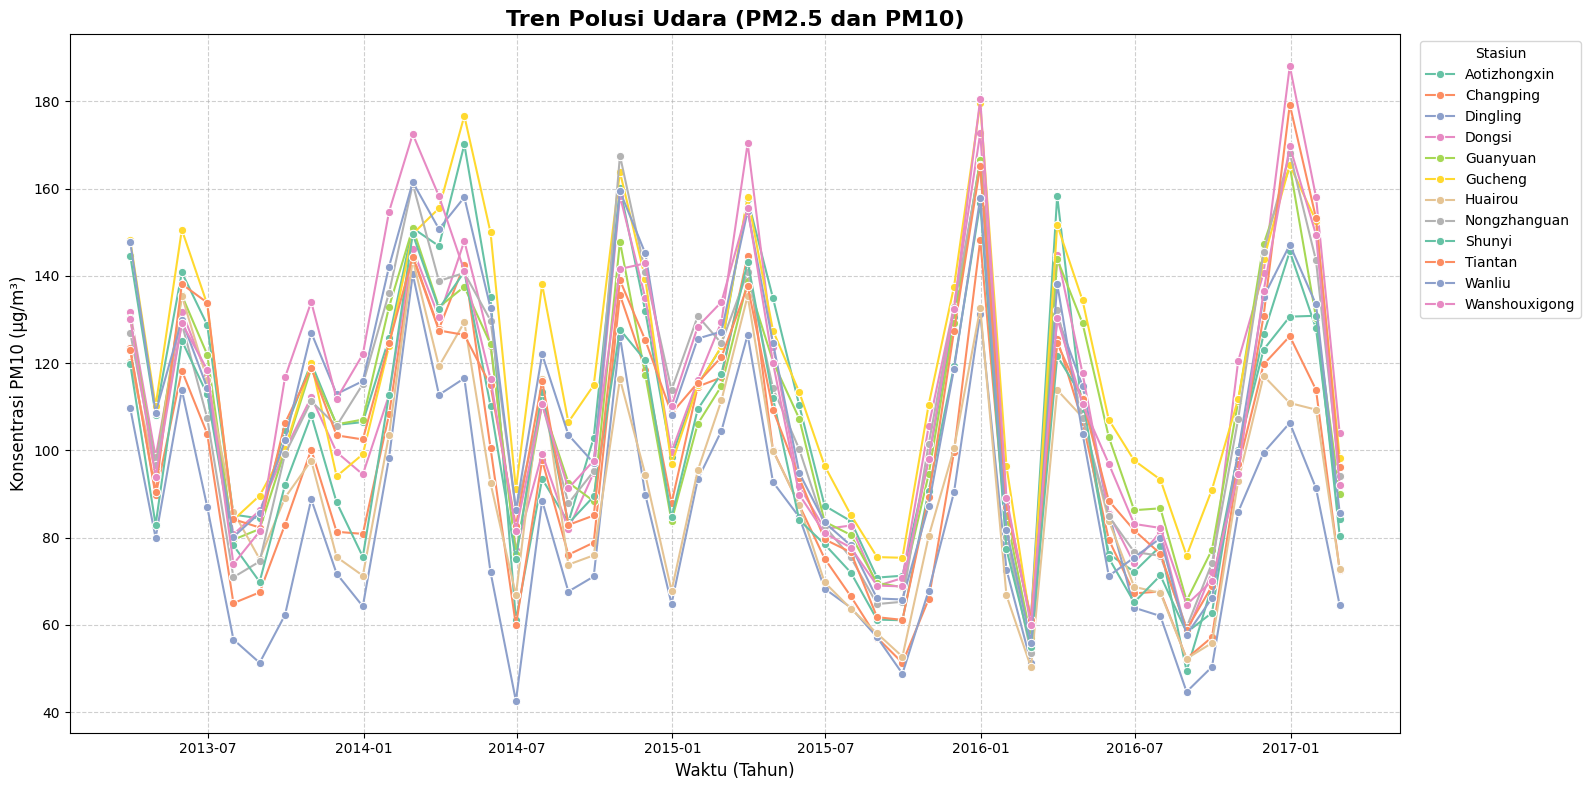

<Figure size 1000x500 with 0 Axes>

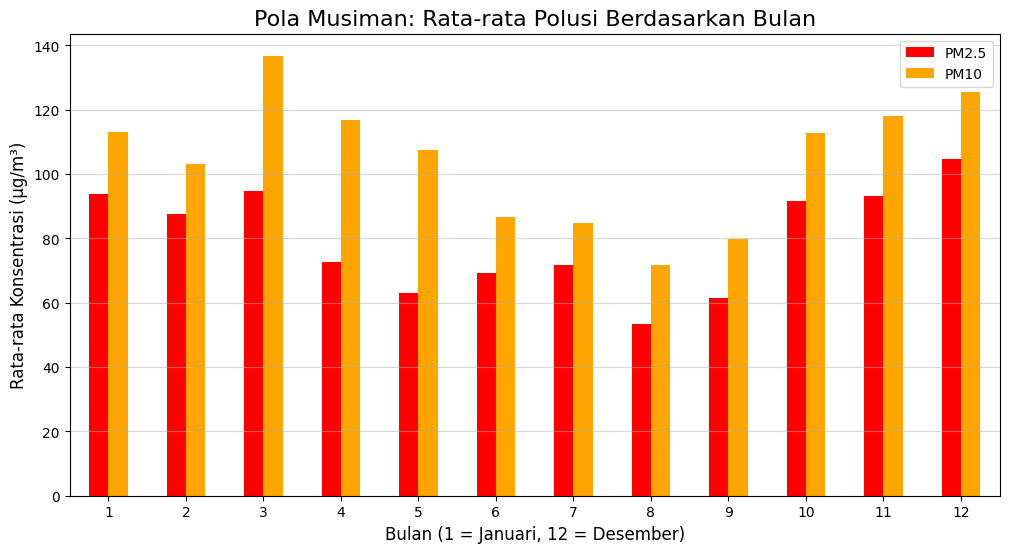

In [25]:
# 1. Tren Jangka Panjang (Bulanan per Tahun)
# Menghitung rata-rata PM10 per bulan untuk setiap stasiun
monthly_station = main_df_clean.groupby(['station', pd.Grouper(key='datetime', freq='ME')])['PM10'].mean().reset_index()


plt.figure(figsize=(16, 8))
sns.lineplot(
    data=monthly_station,
    x='datetime',
    y='PM10',
    hue='station',
    marker='o',
    palette='Set2',
    linewidth=1.5
)
plt.title('Tren Polusi Udara (PM2.5 dan PM10)', fontsize=16, fontweight='bold')
plt.xlabel('Waktu (Tahun)', fontsize=12)
plt.ylabel('Konsentrasi PM10 (µg/m³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Stasiun', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Pola Musiman (Rata-rata Gabungan per Bulan)
monthly_trend = main_df_clean.resample('ME', on='datetime')[['PM2.5', 'PM10']].mean()
seasonal_pattern = main_df_clean.groupby(main_df_clean['datetime'].dt.month)[['PM2.5', 'PM10']].mean()

plt.figure(figsize=(10, 5))
seasonal_pattern.plot(kind='bar', color=['red', 'orange'], figsize=(12, 6))
plt.title('Pola Musiman: Rata-rata Polusi Berdasarkan Bulan', fontsize=16)
plt.xlabel('Bulan (1 = Januari, 12 = Desember)', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi (µg/m³)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.show()



### Pertanyaan 2:

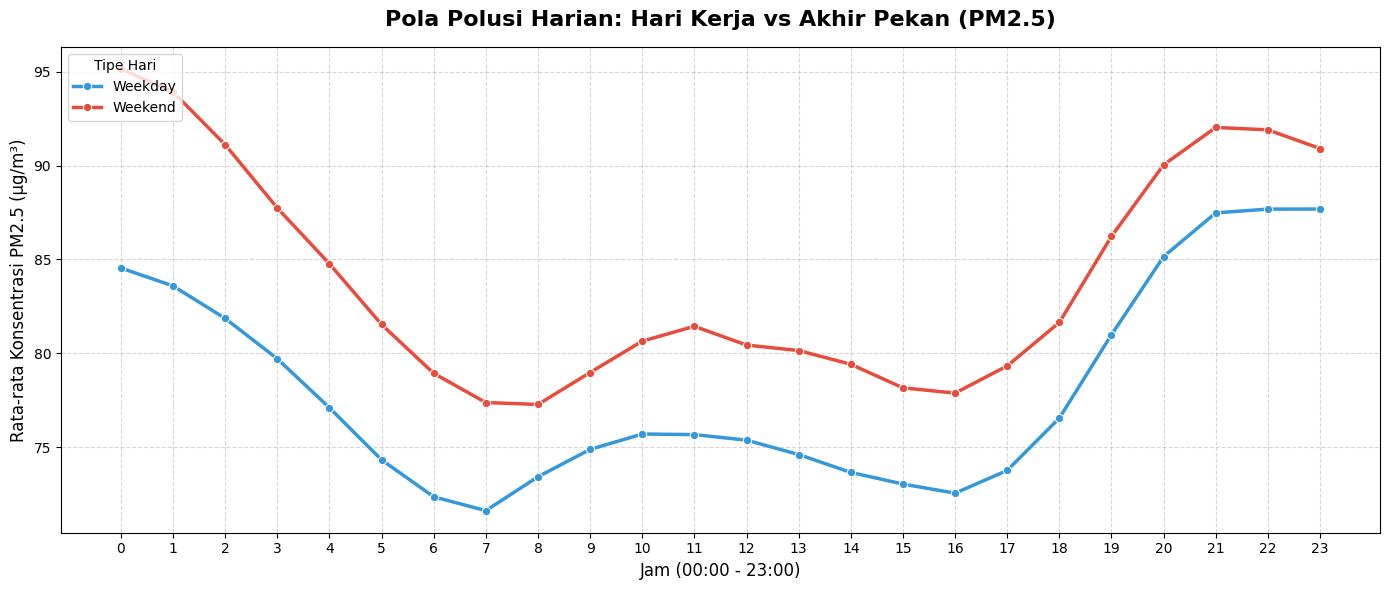

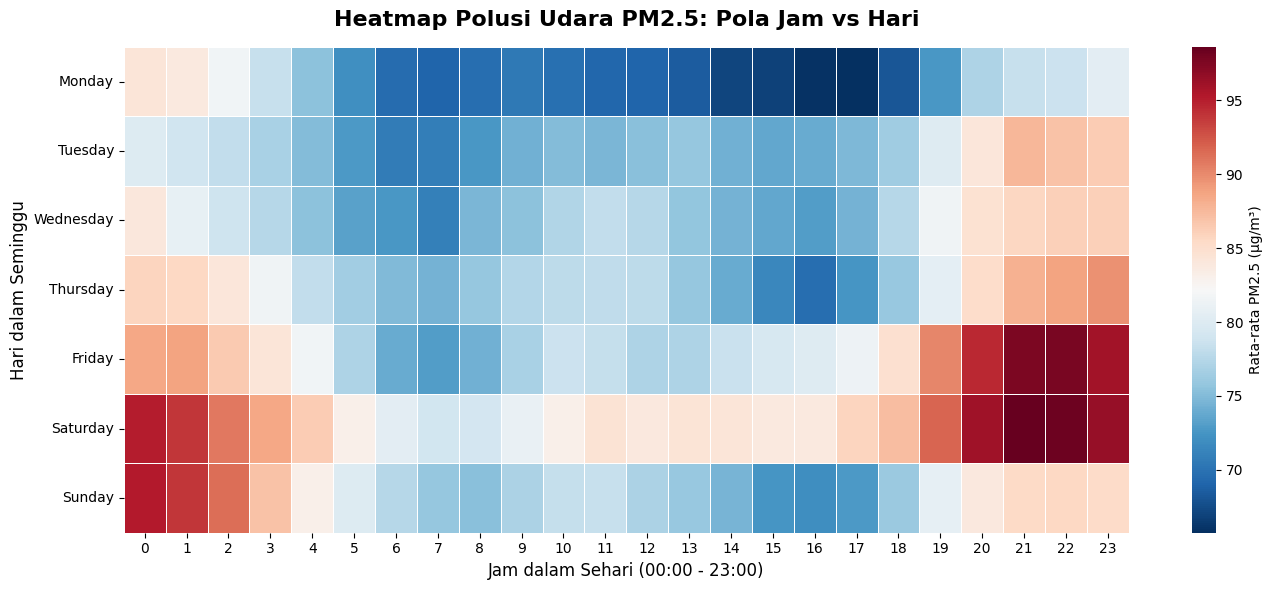

In [27]:
# PERTANYAAN 2: Pola Polusi Harian (Jam Sibuk & Tipe Hari)

# 1. PERSIAPAN DATA (Fitur Waktu)
# Mengekstrak Jam, Nama Hari, dan mendeteksi Tipe Hari langsung ke main_df_clean
main_df_clean['hour'] = main_df_clean['datetime'].dt.hour
main_df_clean['day_name'] = main_df_clean['datetime'].dt.day_name()

# dt.dayofweek: 0=Senin, ..., 4=Jumat, 5=Sabtu, 6=Minggu
main_df_clean['day_type'] = main_df_clean['datetime'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 2. VISUALISASI 1: LINE CHART (Pola Harian Weekday vs Weekend)
# Agregasi data rata-rata PM2.5
hourly_pattern = main_df_clean.groupby(['hour', 'day_type'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=hourly_pattern,
    x='hour',
    y='PM2.5',
    hue='day_type',
    marker='o',
    palette=['#3498db', '#e74c3c'], # Biru (Weekday), Merah (Weekend)
    linewidth=2.5
)

# Estetika Line Chart
plt.title('Pola Polusi Harian: Hari Kerja vs Akhir Pekan (PM2.5)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5) # Garis bantu
plt.legend(title='Tipe Hari', loc='upper left')
plt.tight_layout()
plt.show()


# 3. VISUALISASI 2: HEATMAP (Pola Jam vs Nama Hari)
# Membuat Pivot Table menggunakan data yang sama
pivot_time = main_df_clean.pivot_table(values='PM2.5', index='day_name', columns='hour', aggfunc='mean')

# Mengurutkan baris dari Senin hingga Minggu
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_time = pivot_time.reindex(days_order)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_time,
    cmap='RdBu_r',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Rata-rata PM2.5 (µg/m³)'}
)

# Estetika Heatmap
plt.title('Heatmap Polusi Udara PM2.5: Pola Jam vs Hari', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jam dalam Sehari (00:00 - 23:00)', fontsize=12)
plt.ylabel('Hari dalam Seminggu', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Pertanyaan 3

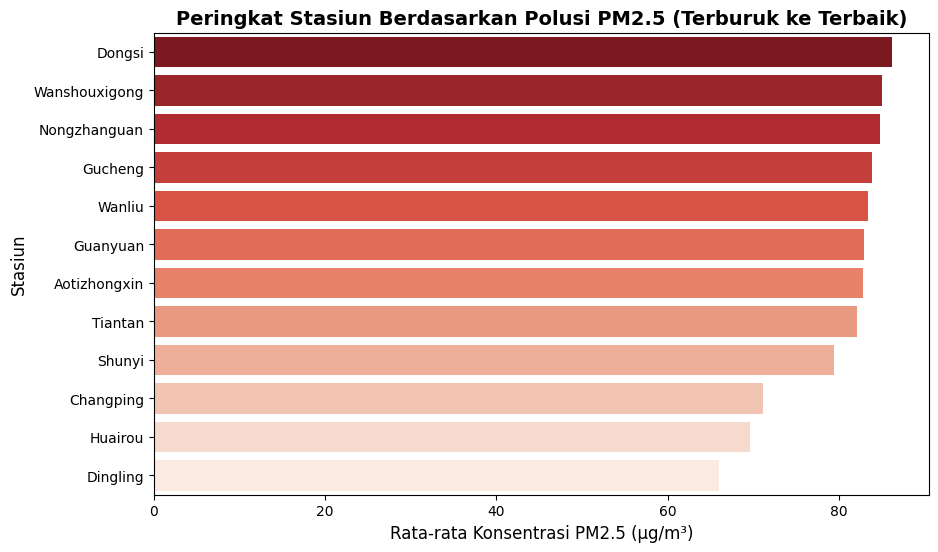

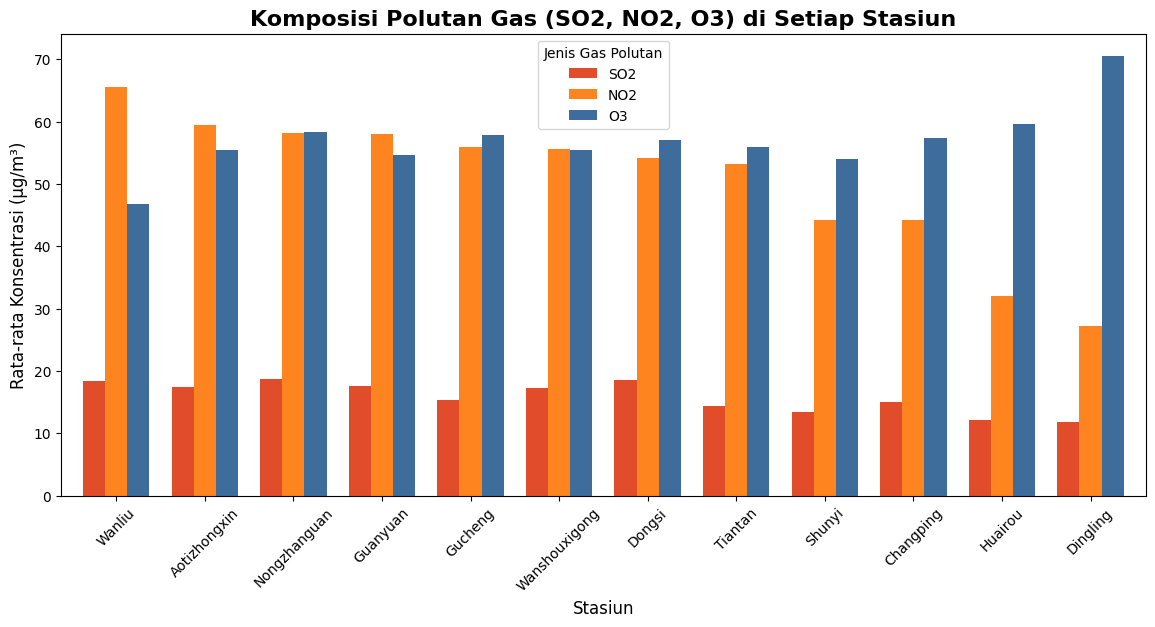

In [28]:
#Pertanyaan 3
# Stasiun Terburuk vs Terbaik
station_avg = main_df_clean.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
# Menggunakan hue dan legend=False agar bebas warning
sns.barplot(data=station_avg, x='PM2.5', y='station', hue='station', palette='Reds_r', legend=False)
plt.title('Peringkat Stasiun Berdasarkan Polusi PM2.5 (Terburuk ke Terbaik)', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.ylabel('Stasiun', fontsize=12)
plt.show()

# Komposisi Polutan Lain (SO2, NO2, O3)
# Mengambil 3 gas polutan utama selain partikel debu
komposisi_cols = ['SO2', 'NO2', 'O3']
# Mengurutkan stasiun berdasarkan stasiun dengan NO2 tertinggi
station_comp = main_df_clean.groupby('station')[komposisi_cols].mean().sort_values(by='NO2', ascending=False)

# Plotting Grouped Bar Chart
station_comp.plot(kind='bar', figsize=(14, 6), width=0.75, color=['#e14d2a', '#fd841f', '#3e6d9c'])
plt.title('Komposisi Polutan Gas (SO2, NO2, O3) di Setiap Stasiun', fontsize=16, fontweight='bold')
plt.xlabel('Stasiun', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi (µg/m³)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Jenis Gas Polutan')
plt.show()

**Insight:**
- Pertanyaan 1

Berdasarkan Tren Polusi Udara (PM2.5 dan PM10) di Beijing yang digambarkan dengan line chart, terlihat bahwa polusi PM2.5 dan PM10 menunjukan pola siklus yang berulang. Hal ini terlihat dari adanya pola gunung dan lembah yang konsisten. contohnya lonjokan polusi atau pola gunung terjadi di 2016-01 dan 2017-01. selain itu pola lembah terjadi di 2015-07 dan 2016-07

Berdasarkan grafik pola musiman menunjukkan bahwa rata-rata polusi berdasarkan bulan yang digambarkan dengan bar chart menunjukan bahwa terjadi pola musiman dan terdapat lonjakan polusi. contohnya konsentrasi polutan memuncak pada bulan Oktober hingga Maret, dengan bulan Desember dan Maret sebagai titik terparah. Secara iklim, ini adalah periode Musim Dingin (Winter) di Tiongkok. Selain itu, kualitas udara mencapai titik terendah pada pertengahan tahun, khususnya di bulan Agustus (bulan 8). Pada musim panas, suhu udara yang lebih panas membuat partikel polusi lebih mudah menyebar ke atmosfer atas. Tambahan pula, kecepatan angin yang lebih tinggi di musim panas membantu mengurangi debu polusi dari udara.

Dari kedua grafik, terlihat pergerakan garis merah (PM2.5) dan garis oranye (PM10) selalu searah. Meskipun kadar PM10 (partikel kasar) secara volume selalu lebih besar dari PM2.5 (partikel halus), keduanya mungkin berasal dari sumber emisi yang sama atau sangat berkaitan erat.

- Pertanyaan 2

Pola polusi harian: hari kerja vs Akhir Pekan (PM2.5). Berdasarkan grafik Line chart rata-rata pergerakan PM2.5 per jam, terbentuk pola U-shape baik pada hari kerja maupun akhir pekan. titik terendah pada sore hari pukul 15.00-16.00 dan titik tertinggi terjadi pada dini hari pukul 21.00-02.00. Garis merah (Weekend) secara konsisten berada di atas garis biru (Weekday) pada hampir setiap jam. Artinya, kualitas udara di akhir pekan rata-rata selalu lebih buruk dibandingkan hari kerja biasa. Akhir pekan seringkali berarti mobilitas yang jauh lebih tinggi dan menyebar untuk rekreasi, hiburan, dan liburan keluarga.
Garis merah di jam 00:00 hingga 01:00 (tengah malam). Lonjakan polusinya sangat tinggi (di atas 90 µg/m³). Ini mengindikasikan tingginya aktivitas rekreasi malam (nightlife) atau kepadatan lalu lintas orang-orang yang pulang larut malam pada hari Jumat/Sabtu malam dibandingkan hari biasa.

selain itu, heatmap pola jam vs hari menunjukkan bahwa semakin merah maka semakin tinggi polusi dan semakin biru blok maka semakin rendah polusi. Pada hari Jumat (Friday), Sabtu (Saturday), dan Minggu (Sunday). Area berwarna merah paling gelap (konsentrasi PM2.5 mencapai >95 µg/m³) sangat pekat dan menumpuk pada malam hari (pukul 20:00 - 23:00) hingga berlanjut ke dini hari (pukul 00:00 - 02:00). Berkebalikan dengan akhir pekan, hari Senin (Monday) hingga Rabu (Wednesday) memiliki area biru gelap yang cukup luas, terutama pada siang hingga sore hari. Di hampir semua hari kecuali Saturday terdapat pola vertikal di mana rentang waktu pukul 13:00 hingga 16:00 didominasi oleh warna biru/terang.


- Pertanyaan 3

Dari grafik Peringkat Stasiun, terlihat jelas adanya ketimpangan kualitas udara antar wilayah:
Stasiun dengan kualitas udara terburuk terletak di Dongsi, Wanshouxigong, dan Nongzhanguan menempati posisi puncak dengan kadar rata-rata PM2.5 tertinggi (di atas 80 µg/m³). Stasiun-stasiun ini umumnya terletak di kawasan pusat kota Beijing yang sangat padat.
Stasiun dengan kulitas udara yang baik seperti di Dingling, Huairou, dan Changping mencatat tingkat PM2.5 terendah (berkisar di angka 60-70 µg/m³). Wilayah-wilayah ini berada di area pinggiran (suburban) bagian utara atau dekat pegunungan yang jauh lebih asri dan berjarak dari pusat industri.

Pada grafik Komposisi Polutan Gas di Setiap Stasiun, perhatikan batang berwarna oranye (NO2). Stasiun-stasiun dengan udara yang kotor (seperti Wanliu, Nongzhanguan, dan Dongsi) memiliki kadar gas Nitrogen Dioksida (NO2) yang mendominasi. Karena NO2 adalah gas buang utama dari knalpot kendaraan bermotor, tingginya angka ini mengkonfirmasi bahwa kemacetan lalu lintas perkotaan adalah salah satu kontributor utama buruknya kualitas udara di wilayah tersebut.

Grafik polutan konsentrasi zat Ozon yang terbaik. stasiun seperti Dingling dan Huairou memiliki konsentrasi PM2.5 dan NO2 yang rendah, namun kadar gas O3(batang berwarna biru) berada di titik tertinggi. Hal ini terjadi karena ozon di perkotaan bereaksi dengan Nitrogen Oksida sisa pembuangan kendaraan bermotor dan industri (proses scavenging atau tirasi), sehingga konsentrasi ozon berkurang secara lokal. Sebaliknya, di daerah pinggiran seperti Dingling yang jarang dilewati kendaraan, ozon dapat terakumulasi secara alami di siang hari tanpa ada banyak emisi gas buang yang menetralkannya.

## Analisis Lanjutan (Opsional)

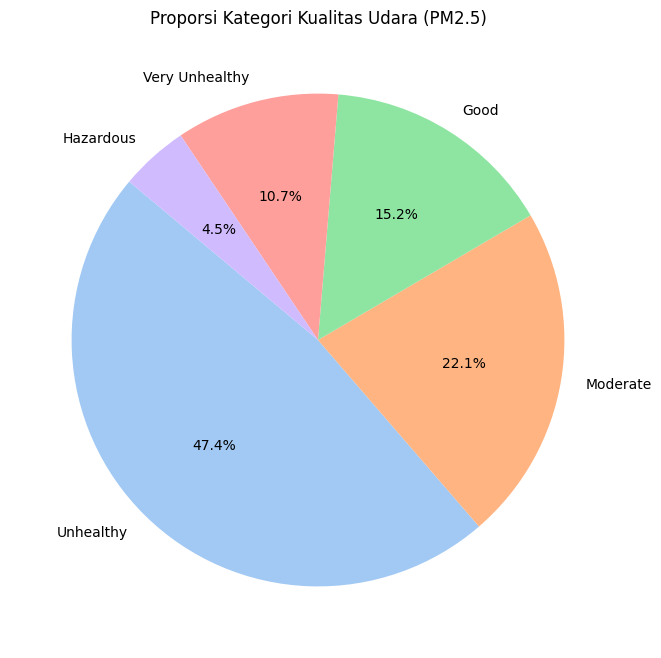

In [29]:
#Mengkategorikan kualitas udara berdasarkan PM2.5
# (Ambang batas disederhanakan dari standar AQI US EPA)
def categorize_air_quality(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    elif pm25 <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# Terapkan fungsi ke kolom baru
main_df_clean['air_quality_category'] = main_df_clean['PM2.5'].apply(categorize_air_quality)

# Visualisasi Distribusi Kategori
category_counts = main_df_clean['air_quality_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proporsi Kategori Kualitas Udara (PM2.5)')
plt.show()

# Simpan dataframe yang sudah bersih
main_df_clean.to_csv("all_data_clean.csv", index=False)

## Conclusion

- Conclution pertanyaan 1

Tren kualitas Udara dengan indikator PM2.5 dan PM10 menunjukkan pola musiman yang konsisten dalam beberapa tahun. Tingkat polusi udara selalu mencapai titik terburuknya pada bulan-bulan musim dingin (Desember, Januari, Februari, Maret) dan menyentuh titik terendah (paling bersih) pada musim panas (Agustus).
Lonjakan tinggi di musim dingin utamanya disebabkan oleh peningkatan masif pembakaran batu bara untuk sistem pemanas di wilayah Beijing. Selain itu, cuaca musim dingin seringkali menciptakan fenomena inversi termal di mana udara dingin di dekat tanah memerangkap asap polusi sehingga tidak bisa terbang ke atas.


- Conclution pertanyaan 2


Dalam satu hari, udara cenderung paling bersih pada sore hari (pukul 15:00 - 16:00), dan secara konsisten mulai memburuk sejak malam hari hingga mencapai puncaknya pada tengah malam/dini hari.

Pola polusi harian membentuk pola U-shape baik pada hari kerja maupun akhir pekan. Dengan konsentrasi PM2.5 akhir pekan yang selalu berada di atas hari kerja hampir setiap jam. tingginya polusi di akhir pekan kemungkinan didorong mobilitas yang jauh lebih tinggi dan menyebar untuk rekreasi, hiburan, dan liburan keluarga. Kemacetan mungkin berpindah dari kawasan perkantoran ke pusat perbelanjaan atau tempat wisata sepanjang hari.


- Conclution pertanyaan 3

Stasiun Dongsi, Wanshouxigong dan Nongzhanguan menempati urutan teratas sebagai wilayah dengan kualitas udara terburuk (PM2.5 tertinggi). Sebaliknya, stasiun Dingling dan Huairou memiliki catatan kualitas udara terbaik (PM2.5 terendah).

Dalam grafik komposisi polutan gas, stasiun yang kualitas udaranya buruk juga memiliki rata-rata gas Nitrogen Dioksida (NO2) yang jauh lebih tinggi dibandingkan stasiun yang kualitas udaranya bersih.

Dongsi, Wanshouxigong dan Nongzhanguan terletak di kawasan pusat kota Beijing yang sangat padat dengan aktivitas urban dan kemacetan, terbukti dari tingginya kadar NO2 (yang merupakan gas buang utama dari knalpot kendaraan bermotor). Sementara itu, Dingling dan Huairou terletak di wilayah pegunungan/suburban utara Beijing, jauh dari kawasan industri dan kepadatan lalu lintas.